In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from itertools import cycle

In [3]:
x,y = make_classification(n_samples=1000,
                     n_features=20,
                     n_classes=3,
                     n_informative=10,
                     random_state=42)
y_bin=label_binarize(y,classes=np.unique(y))

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y_bin,
    test_size=0.2,
    random_state=42
)

In [4]:
logistic_model = OneVsRestClassifier(LogisticRegression(random_state=42))
logistic_model.fit(x_train,y_train)

rf_model = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100,random_state=42)
)
rf_model.fit(x_train,y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",RandomForestC...ndom_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](3,)","[0,1,2]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[RandomForestC...ndom_state=42), RandomForestC...ndom_state=42), RandomForestC...ndom_state=42)]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,True
n_classes_ n_classes_: intNumber of classes.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42


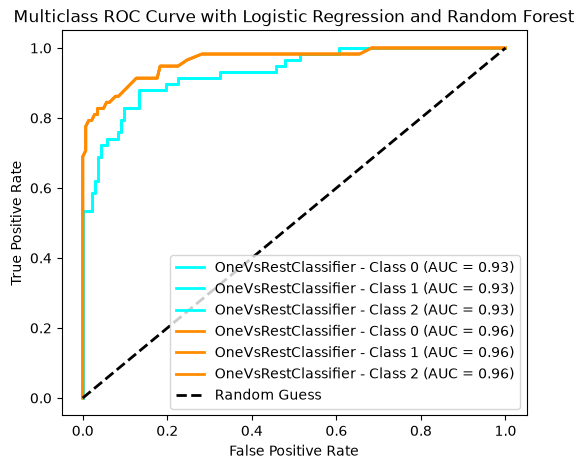

In [5]:
fpr = dict()
tpr = dict()
roc_auc = dict()

models = [logistic_model,rf_model]
plt.figure(figsize=(6,5))
color = cycle(['aqua','darkorange'])

for model ,color in zip(models,color):
    for i in range(model.classes_.shape[0]):
        fpr[i],tpr[i],_ = roc_curve(
            y_test[:,-1],model.predict_proba(x_test)[:,-1]
        )
        roc_auc[i] = auc(fpr[i],tpr[i])
        plt.plot(fpr[i],tpr[i],color=color,lw=2,
                 label=f'{model.__class__.__name__} - Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve with Logistic Regression and Random Forest')
plt.legend(loc="lower right")
plt.show()